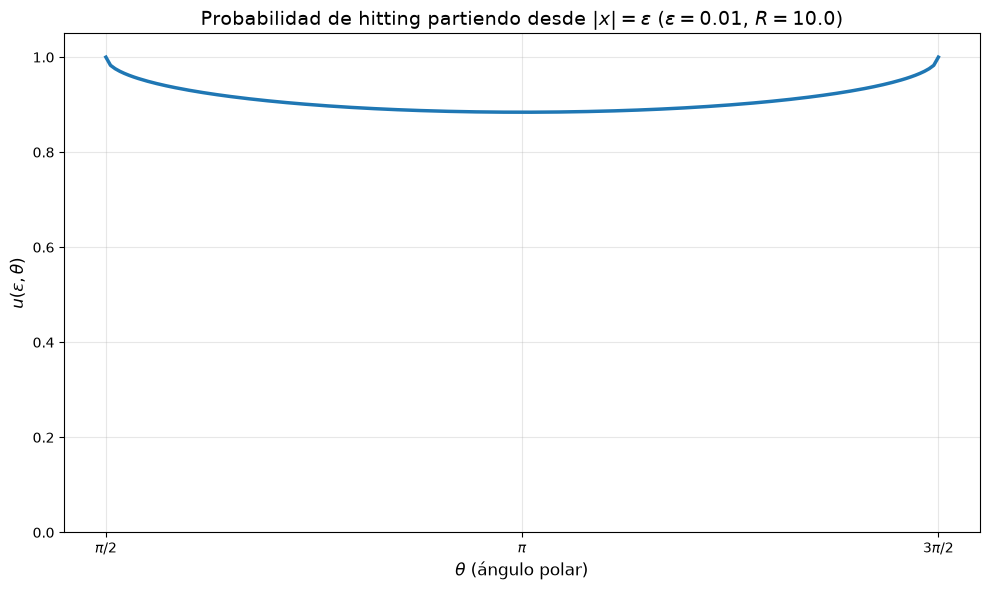

Boundary-integral diagnostics
-----------------------------
N                  = 30
epsilon            = 0.5
R                  = 10.0
||A phi - 1||_inf  = 2.220e-16
cond(A)            = 9.468e+01

u([-5.0, 0.0]) = 0.187269025807

Boundary checks
---------------
u on window       = 1.0
u on outer arc    = 0.0


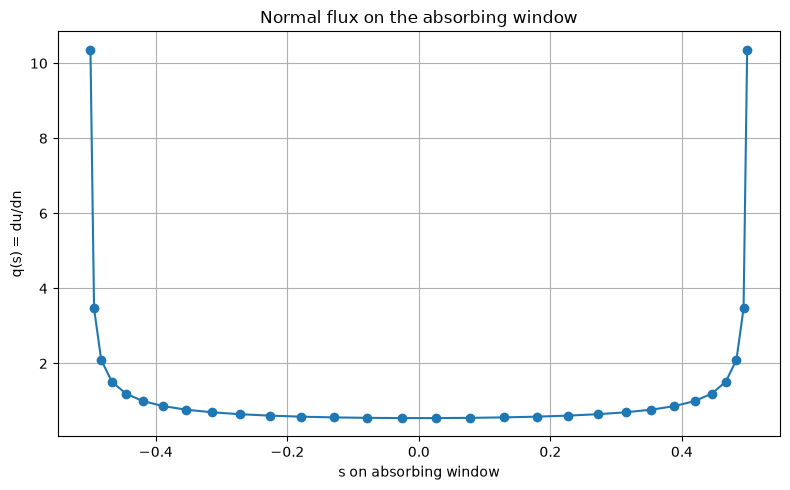

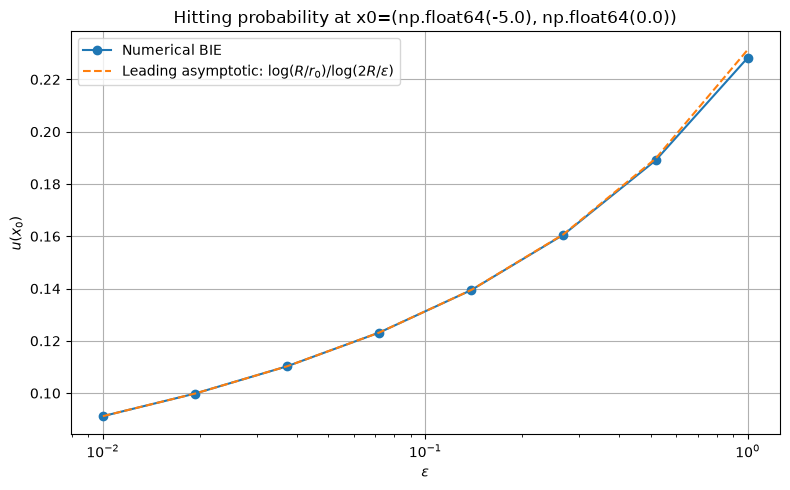

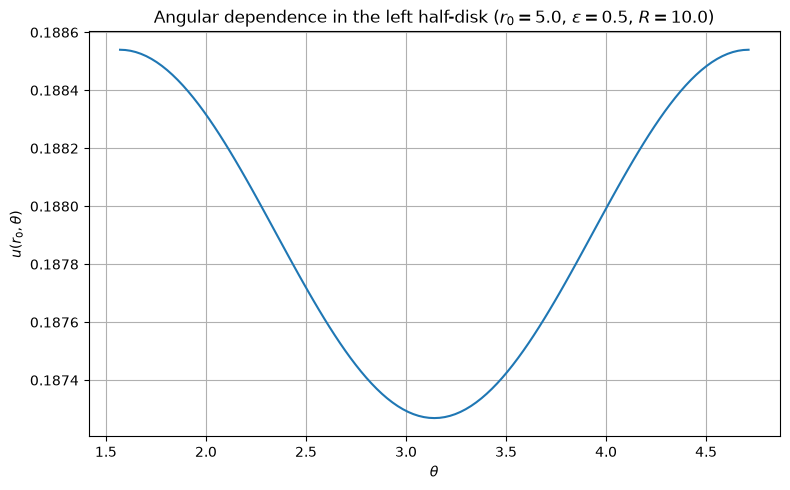

In [6]:
# %% [markdown]
# # Hitting probability in a half-disk with a small absorbing window
#
# Domain:
#   Omega = {(x1,x2): x1 <= 0, x1^2 + x2^2 < R^2}
#
# Boundary conditions for the splitting / hitting probability:
#
#   Delta u = 0                         in Omega
#   u = 1                               on Gamma_a = {(0,s): |s| <= epsilon}
#   u = 0                               on the outer semicircle |x| = R
#   du/dn = 0                           on the remaining flat boundary
#
# Thus u(x) = P_x(tau_window < tau_outer).
#
# We solve a first-kind boundary integral equation for the UNKNOWN NORMAL FLUX
# q = du/dn on Gamma_a.  We do NOT solve for u on Gamma_a, because u=1 there.
#
# The Green function used below satisfies:
#
#   -Delta_y G_H(x,y) = delta_x(y)
#   G_H = 0       on the outer semicircle
#   dG_H/dn = 0   on the whole flat diameter
#
# It is constructed from the Dirichlet Green function of the full disk by
# reflection across x1=0:
#
#   G_H(x,y) = G_B(x,y) + G_B(x,y_reflected).
#
# For y=(0,t) on the flat boundary this simplifies to the explicit expression
# implemented in green_half_disk_boundary_source().
#
# On the absorbing window, Green's representation gives:
#
#   1 = integral_{-epsilon}^{epsilon} G_H((0,s),(0,t)) q(t) dt.
#
# The flux has the endpoint behavior
#
#   q(t) ~ 1/sqrt(epsilon^2-t^2).
#
# We therefore set
#
#   t = epsilon*cos(theta),
#   q(t) = phi(theta)/sqrt(epsilon^2-t^2),
#
# so that q(t) dt = phi(theta) dtheta (up to orientation).  The transformed
# unknown phi is smooth and is discretized by piecewise constants.

# %%
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.linalg import solve


# %% [markdown]
# ## 1. Green function

# %%
def _validate_geometry(epsilon, R):
    if R <= 0:
        raise ValueError("R must be positive.")
    if epsilon <= 0:
        raise ValueError("epsilon must be positive.")
    if epsilon >= R:
        raise ValueError("Need 0 < epsilon < R.")


def green_half_disk_boundary_source(x, t, R):
    """
    Mixed Green function G_H(x,(0,t)) for the half-disk.

    Boundary conditions of G_H:
      * Dirichlet on the outer semicircle |x|=R,
      * Neumann on the flat diameter x1=0.

    Parameters
    ----------
    x : array_like, shape (2,)
        Observation point in the left half-disk.
    t : float
        Source coordinate on the flat diameter, y=(0,t).
    R : float
        Disk radius.

    Returns
    -------
    float
        G_H(x,(0,t)).

    Notes
    -----
    For x=(x1,x2), one obtains the stable closed form

        G_H(x,(0,t))
          = (1/pi) log(
                sqrt((x1*t)^2 + (x2*t - R^2)^2)
                /
                (R*sqrt(x1^2 + (x2-t)^2))
            ).

    It is logarithmically singular when x=(0,t).
    """
    x = np.asarray(x, dtype=float)
    if x.shape != (2,):
        raise ValueError("x must have shape (2,).")

    x1, x2 = x

    numerator = np.hypot(x1 * t, x2 * t - R**2)
    denominator = R * np.hypot(x1, x2 - t)

    if denominator == 0.0:
        return np.inf

    return np.log(numerator / denominator) / np.pi


def window_kernel(s, t, R):
    """
    Trace of the mixed Green function on the absorbing window:

        K(s,t)
          = G_H((0,s),(0,t))
          = (1/pi) log((R^2 - s*t)/(R*|s-t|)).

    The singularity at s=t is logarithmic and therefore integrable.
    """
    distance = abs(s - t)
    if distance == 0.0:
        return np.inf

    return np.log((R**2 - s * t) / (R * distance)) / np.pi


# %% [markdown]
# ## 2. Boundary integral equation for the flux

# %%
def assemble_flux_system(N, epsilon, R, epsabs=1e-11, epsrel=1e-11):
    """
    Assemble the collocation system for the transformed flux phi.

    We use:
        t = epsilon*cos(theta),
        q(t) = phi(theta)/sqrt(epsilon^2-t^2),

    and approximate phi by a constant on each theta-panel.

    The integral equation is

        integral_0^pi K(s_i, epsilon*cos(theta)) phi(theta) dtheta = 1.

    Midpoints are used as collocation points.  The logarithmic singularity of
    the diagonal panel is integrated directly by splitting the quadrature
    interval at the collocation point.

    Returns
    -------
    A : ndarray, shape (N,N)
    s_nodes : ndarray, shape (N,)
        Physical collocation points on the window.
    theta_edges : ndarray, shape (N+1,)
    theta_mid : ndarray, shape (N,)
    """
    _validate_geometry(epsilon, R)

    if N < 4:
        raise ValueError("Use N >= 4.")

    theta_edges = np.linspace(0.0, np.pi, N + 1)
    theta_mid = 0.5 * (theta_edges[:-1] + theta_edges[1:])
    s_nodes = epsilon * np.cos(theta_mid)

    A = np.empty((N, N), dtype=float)

    for i, s_i in enumerate(s_nodes):
        for j in range(N):
            a = theta_edges[j]
            b = theta_edges[j + 1]

            def integrand(theta):
                t = epsilon * np.cos(theta)
                return window_kernel(s_i, t, R)

            if i == j:
                # The singularity is logarithmic and integrable.
                c = theta_mid[i]
                left, _ = quad(
                    integrand, a, c,
                    epsabs=epsabs, epsrel=epsrel, limit=100
                )
                right, _ = quad(
                    integrand, c, b,
                    epsabs=epsabs, epsrel=epsrel, limit=100
                )
                A[i, j] = left + right
            else:
                A[i, j], _ = quad(
                    integrand, a, b,
                    epsabs=epsabs, epsrel=epsrel, limit=100
                )

    return A, s_nodes, theta_edges, theta_mid


def solve_window_flux(N, epsilon, R):
    """
    Solve the boundary integral equation for the absorbing-window flux.

    Returns a dictionary containing both the smooth transformed flux phi and
    the physical midpoint values of q.
    """
    A, s_nodes, theta_edges, theta_mid = assemble_flux_system(
        N=N, epsilon=epsilon, R=R
    )

    rhs = np.ones(N)
    phi = solve(A, rhs)

    # Since sqrt(epsilon^2-t^2) = epsilon*sin(theta) for theta in (0,pi):
    q_mid = phi / (epsilon * np.sin(theta_mid))

    residual_inf = np.linalg.norm(A @ phi - rhs, ord=np.inf)

    return {
        "N": N,
        "epsilon": epsilon,
        "R": R,
        "A": A,
        "s_nodes": s_nodes,
        "theta_edges": theta_edges,
        "theta_mid": theta_mid,
        "phi": phi,
        "q_mid": q_mid,
        "residual_inf": residual_inf,
        "condition_number": np.linalg.cond(A),
    }


# %% [markdown]
# ## 3. Evaluate the hitting probability inside the half-disk

# %%
def hitting_probability(x, solution, epsabs=1e-10, epsrel=1e-10):
    """
    Evaluate

        u(x) = integral_{Gamma_a} G_H(x,y) q(y) ds_y

    using the transformed variable theta.
    """
    x = np.asarray(x, dtype=float)

    epsilon = solution["epsilon"]
    R = solution["R"]
    theta_edges = solution["theta_edges"]
    phi = solution["phi"]

    if x.shape != (2,):
        raise ValueError("x must have shape (2,).")

    if x[0] > 1e-12:
        raise ValueError("x is outside the left half-disk: need x1 <= 0.")

    r = np.linalg.norm(x)
    if r > R + 1e-12:
        raise ValueError("x is outside the disk.")

    # Exact boundary values.
    if abs(x[0]) <= 1e-12 and abs(x[1]) <= epsilon:
        return 1.0

    if abs(r - R) <= 1e-12:
        return 0.0

    value = 0.0

    for j, phi_j in enumerate(phi):
        a = theta_edges[j]
        b = theta_edges[j + 1]

        def integrand(theta):
            t = epsilon * np.cos(theta)
            return (
                green_half_disk_boundary_source(x, t, R)
                * phi_j
            )

        panel_value, _ = quad(
            integrand, a, b,
            epsabs=epsabs, epsrel=epsrel, limit=100
        )
        value += panel_value

    return float(value)


# %% [markdown]
# ## 4. Diagnostics and meaningful plots

# %%
def plot_window_flux(solution):
    """
    Plot the physical normal flux q on the window.

    q diverges like 1/sqrt(epsilon^2-s^2) near the two endpoints; this is
    expected for a mixed Dirichlet-Neumann junction.
    """
    s = solution["s_nodes"]
    q = solution["q_mid"]

    order = np.argsort(s)

    plt.figure(figsize=(8, 5))
    plt.plot(s[order], q[order], "o-")
    plt.xlabel("s on absorbing window")
    plt.ylabel("q(s) = du/dn")
    plt.title("Normal flux on the absorbing window")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


def plot_probability_vs_epsilon(
    epsilon_values,
    R,
    x0,
    N=30,
):
    """
    Plot the probability at ONE FIXED INTERIOR STARTING POINT x0.

    This is meaningful; plotting max(u) is not, because max(u)=1 by the
    Dirichlet condition on the absorbing window.

    For a fixed point away from the window and epsilon/R -> 0, the leading
    approximation for this centered geometry is

        u(x0) ~ log(R/|x0|) / log(2R/epsilon).
    """
    x0 = np.asarray(x0, dtype=float)
    r0 = np.linalg.norm(x0)

    if r0 <= 0 or r0 >= R:
        raise ValueError("x0 must satisfy 0 < |x0| < R.")
    if x0[0] >= 0:
        raise ValueError("Choose an interior point with x0[0] < 0.")

    epsilon_values = np.asarray(epsilon_values, dtype=float)

    numerical = []
    asymptotic = []

    for epsilon in epsilon_values:
        if epsilon >= r0:
            raise ValueError(
                "For this comparison choose epsilon < |x0|, "
                "so x0 stays away from the window."
            )

        sol = solve_window_flux(N=N, epsilon=epsilon, R=R)
        numerical.append(hitting_probability(x0, sol))
        asymptotic.append(
            np.log(R / r0) / np.log(2.0 * R / epsilon)
        )

    numerical = np.asarray(numerical)
    asymptotic = np.asarray(asymptotic)

    plt.figure(figsize=(8, 5))
    plt.semilogx(epsilon_values, numerical, "o-", label="Numerical BIE")
    plt.semilogx(
        epsilon_values,
        asymptotic,
        "--",
        label=r"Leading asymptotic: $\log(R/r_0)/\log(2R/\epsilon)$",
    )
    plt.xlabel(r"$\epsilon$")
    plt.ylabel(r"$u(x_0)$")
    plt.title(f"Hitting probability at x0={tuple(x0)}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return numerical, asymptotic


def plot_angular_dependence(
    epsilon,
    R,
    r0,
    N=30,
    number_of_angles=121,
):
    """
    Evaluate u on the circle |x|=r0 INSIDE the left half-disk.

    Because Omega is the LEFT half-disk, only
        theta in [pi/2, 3*pi/2]
    belongs to the domain.
    """
    _validate_geometry(epsilon, R)

    if not (epsilon < r0 < R):
        raise ValueError("Choose epsilon < r0 < R.")

    solution = solve_window_flux(N=N, epsilon=epsilon, R=R)

    theta = np.linspace(np.pi / 2.0, 3.0 * np.pi / 2.0, number_of_angles)
    probability = np.empty_like(theta)

    for k, angle in enumerate(theta):
        x = np.array([
            r0 * np.cos(angle),
            r0 * np.sin(angle),
        ])
        probability[k] = hitting_probability(x, solution)

    plt.figure(figsize=(8, 5))
    plt.plot(theta, probability)
    plt.xlabel(r"$\theta$")
    plt.ylabel(r"$u(r_0,\theta)$")
    plt.title(
        rf"Angular dependence in the left half-disk "
        rf"($r_0={r0}$, $\epsilon={epsilon}$, $R={R}$)"
    )
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    return theta, probability

def plot_probability_vs_epsilon(
    epsilon_values,
    R,
    x0,
    N=30,
):
    """
    Plot the probability at ONE FIXED INTERIOR STARTING POINT x0.

    This is meaningful; plotting max(u) is not, because max(u)=1 by the
    Dirichlet condition on the absorbing window.

    For a fixed point away from the window and epsilon/R -> 0, the leading
    approximation for this centered geometry is

        u(x0) ~ log(R/|x0|) / log(2R/epsilon).
    """
    x0 = np.asarray(x0, dtype=float)
    r0 = np.linalg.norm(x0)

    if r0 <= 0 or r0 >= R:
        raise ValueError("x0 must satisfy 0 < |x0| < R.")
    if x0[0] >= 0:
        raise ValueError("Choose an interior point with x0[0] < 0.")

    epsilon_values = np.asarray(epsilon_values, dtype=float)

    numerical = []
    asymptotic = []

    for epsilon in epsilon_values:
        if epsilon >= r0:
            raise ValueError(
                "For this comparison choose epsilon < |x0|, "
                "so x0 stays away from the window."
            )

        sol = solve_window_flux(N=N, epsilon=epsilon, R=R)
        numerical.append(hitting_probability(x0, sol))
        asymptotic.append(
            np.log(R / r0) / np.log(2.0 * R / epsilon)
        )

    numerical = np.asarray(numerical)
    asymptotic = np.asarray(asymptotic)

    plt.figure(figsize=(8, 5))
    plt.semilogx(epsilon_values, numerical, "o-", label="Numerical BIE")
    plt.semilogx(
        epsilon_values,
        asymptotic,
        "--",
        label=r"Leading asymptotic: $\log(R/r_0)/\log(2R/\epsilon)$",
    )
    plt.xlabel(r"$\epsilon$")
    plt.ylabel(r"$u(x_0)$")
    plt.title(f"Hitting probability at x0={tuple(x0)}")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

    return numerical, asymptotic


def plot_angular_dependence_on_window_boundary(
    epsilon,
    R,
    N=30,
    number_of_angles=181,
):
    """
    Evalúa u(x) para puntos en la circunferencia |x| = epsilon,
    pero estrictamente dentro del semiplano izquierdo (x1 < 0).

    Parámetros
    ----------
    epsilon : float
        Tamaño de la ventana absorbente y radio de la circunferencia inicial.
    R : float
        Radio del círculo exterior.
    N : int
        Número de paneles en la discretización de la ventana.
    number_of_angles : int
        Número de ángulos a evaluar.
    """
    _validate_geometry(epsilon, R)
    
    # Resolvemos la ecuación integral para el flujo UNA SOLA VEZ
    solution = solve_window_flux(N=N, epsilon=epsilon, R=R)

    # Ángulos en el semiplano izquierdo, ligeramente alejados de los bordes
    # para evitar evaluar justo donde u=1 exactamente.
    theta_min = np.pi / 2.0 + 1e-6
    theta_max = 3.0 * np.pi / 2.0 - 1e-6
    theta = np.linspace(theta_min, theta_max, number_of_angles)
    
    probability = np.empty_like(theta)

    for k, angle in enumerate(theta):
        # Punto sobre la circunferencia de radio epsilon
        x = np.array([
            epsilon * np.cos(angle),
            epsilon * np.sin(angle),
        ])
        # Como x1 < 0, estamos en el interior. La integral es regular.
        probability[k] = hitting_probability(x, solution)

    # Graficamos
    plt.figure(figsize=(10, 6))
    plt.plot(theta, probability, linewidth=2.5)
    plt.xlabel(r"$\theta$ (ángulo polar)", fontsize=12)
    plt.ylabel(r"$u(\epsilon, \theta)$", fontsize=12)
    plt.title(
        rf"Probabilidad de hitting partiendo desde $|x| = \epsilon$ "
        rf"($\epsilon={epsilon}$, $R={R}$)",
        fontsize=14
    )
    plt.xticks(
        [np.pi/2, np.pi, 3*np.pi/2],
        [r'$\pi/2$', r'$\pi$', r'$3\pi/2$']
    )
    plt.grid(True, alpha=0.3)
    plt.ylim([0, 1.05])
    plt.tight_layout()
    plt.show()

    return theta, probability

# EJECUCIÓN
if __name__ == "__main__":
    R = 10.0
    epsilon = 0.01
    N = 40  # Un poco más de resolución

    # ¡Aquí evaluamos justo en |x| = epsilon!
    theta, prob = plot_angular_dependence_on_window_boundary(
        epsilon=epsilon,
        R=R,
        N=N
    )


# %% [markdown]
# ## 5. Main execution

# %%
if __name__ == "__main__":
    R = 10.0
    epsilon = 0.5
    N = 30

    solution = solve_window_flux(N=N, epsilon=epsilon, R=R)

    print("Boundary-integral diagnostics")
    print("-----------------------------")
    print(f"N                  = {N}")
    print(f"epsilon            = {epsilon}")
    print(f"R                  = {R}")
    print(f"||A phi - 1||_inf  = {solution['residual_inf']:.3e}")
    print(f"cond(A)            = {solution['condition_number']:.3e}")

    x0 = np.array([-5.0, 0.0])
    u0 = hitting_probability(x0, solution)
    print(f"\nu({x0.tolist()}) = {u0:.12f}")

    # Boundary checks:
    print("\nBoundary checks")
    print("---------------")
    print(
        "u on window       =",
        hitting_probability(np.array([0.0, 0.0]), solution),
    )
    print(
        "u on outer arc    =",
        hitting_probability(np.array([-R, 0.0]), solution),
    )

    plot_window_flux(solution)

    eps_values = np.logspace(-2, 0, 8)
    plot_probability_vs_epsilon(
        epsilon_values=eps_values,
        R=R,
        x0=x0,
        N=N,
    )

    plot_angular_dependence(
        epsilon=epsilon,
        R=R,
        r0=5.0,
        N=N,
    )

Calculando para 20 valores de epsilon...
  epsilon = 0.0100... ¡Listo!
  epsilon = 0.0140... ¡Listo!
  epsilon = 0.0197... ¡Listo!
  epsilon = 0.0277... ¡Listo!
  epsilon = 0.0389... ¡Listo!
  epsilon = 0.0546... ¡Listo!
  epsilon = 0.0766... ¡Listo!
  epsilon = 0.1075... ¡Listo!
  epsilon = 0.1510... ¡Listo!
  epsilon = 0.2120... ¡Listo!
  epsilon = 0.2976... ¡Listo!
  epsilon = 0.4179... ¡Listo!
  epsilon = 0.5867... ¡Listo!
  epsilon = 0.8237... ¡Listo!
  epsilon = 1.1565... ¡Listo!
  epsilon = 1.6238... ¡Listo!
  epsilon = 2.2798... ¡Listo!
  epsilon = 3.2008... ¡Listo!
  epsilon = 4.4940... ¡Listo!
  epsilon = 6.3096... ¡Listo!


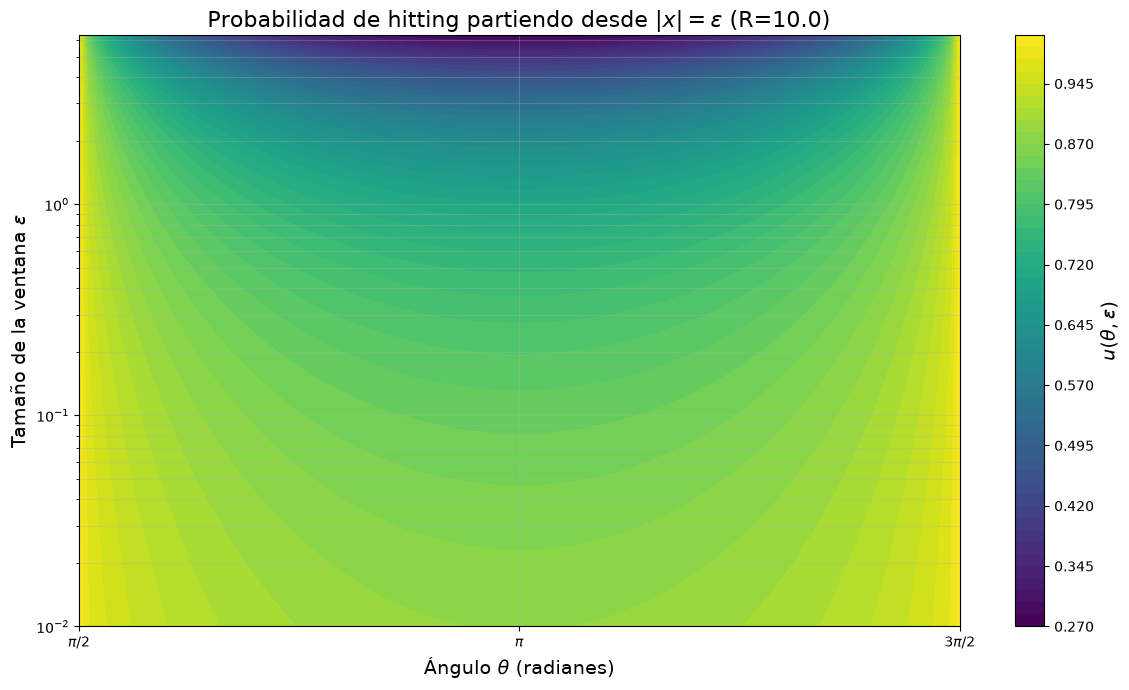

In [7]:
def plot_hitting_contour_vs_epsilon_and_angle(R, eps_range, N=25, n_angles=80):
    """
    Genera un mapa de contorno de la probabilidad de hitting u(theta, epsilon)
    para puntos de inicio en la circunferencia |x| = epsilon.
    
    Parámetros
    ----------
    R : float
        Radio del círculo exterior.
    eps_range : array_like
        Lista de valores de epsilon a explorar (se recomienda escala logarítmica).
    N : int
        Número de paneles para discretizar la ventana (resolución del BIE).
    n_angles : int
        Número de ángulos en el semiplano izquierdo.
    """
    # Ángulos estrictamente en el interior del semiplano izquierdo (evitamos x1=0 exacto)
    theta_min = np.pi / 2.0 + 1e-4
    theta_max = 3.0 * np.pi / 2.0 - 1e-4
    theta_range = np.linspace(theta_min, theta_max, n_angles)
    
    # Matriz de resultados: filas = ángulos, columnas = epsilons
    U = np.zeros((len(theta_range), len(eps_range)))
    
    print(f"Calculando para {len(eps_range)} valores de epsilon...")
    for j, eps in enumerate(eps_range):
        print(f"  epsilon = {eps:.4f}...", end="", flush=True)
        # 1. Resolvemos el problema integral UNA VEZ por cada epsilon
        sol = solve_window_flux(N=N, epsilon=eps, R=R)
        
        # 2. Evaluamos la probabilidad en todos los ángulos para este epsilon
        for i, theta in enumerate(theta_range):
            # Punto de inicio sobre la circunferencia de radio eps
            x_start = np.array([eps * np.cos(theta), eps * np.sin(theta)])
            # Como x1 < 0, la función de Green es regular
            U[i, j] = hitting_probability(x_start, sol)
        print(" ¡Listo!")
    
    # --- Visualización ---
    # Creamos la malla para el contour plot
    Theta, Eps = np.meshgrid(theta_range, eps_range, indexing='ij')
    
    plt.figure(figsize=(12, 7))
    
    # Usamos contourf con muchos niveles para suavidad
    contour = plt.contourf(Theta, Eps, U, levels=60, cmap='viridis')
    cbar = plt.colorbar(contour)
    cbar.set_label(r'$u(\theta, \varepsilon)$', fontsize=14)
    
    # Configuración de ejes
    plt.xlabel(r'Ángulo $\theta$ (radianes)', fontsize=14)
    plt.ylabel(r'Tamaño de la ventana $\varepsilon$', fontsize=14)
    plt.yscale('log')  # ¡Escala logarítmica para ver el comportamiento asintótico!
    
    # Marcas en el eje X
    plt.xticks(
        [np.pi/2, np.pi, 3*np.pi/2],
        [r'$\pi/2$', r'$\pi$', r'$3\pi/2$']
    )
    
    plt.title(
        rf'Probabilidad de hitting partiendo desde $|x| = \varepsilon$ (R={R})',
        fontsize=16
    )
    plt.grid(True, alpha=0.3, which='both')
    plt.tight_layout()
    plt.show()
    
    return theta_range, eps_range, U

# --- EJECUCIÓN EN TU NOTEBOOK ---
if __name__ == "__main__":
    R = 10.0
    # Exploramos desde epsilon muy pequeño hasta casi R
    eps_values = np.logspace(-2, 0.8, 20)  # 0.01 a ~6.3
    
    theta, eps, U = plot_hitting_contour_vs_epsilon_and_angle(
        R=R,
        eps_range=eps_values,
        N=25,          # Resolución del BIE (puedes aumentarlo a 30 si quieres más precisión)
        n_angles=100
    )

In [14]:
import numpy as np

from scipy.integrate import quad
from scipy.linalg import solve
from scipy.special import ellipk, ellipkm1, gamma


class NarrowEscapeSolverD:
    """
    Base class for the hitting probability in a d-dimensional half-ball.

    Domain
    ------
        Omega = {x1 <= 0, ||x|| < R}

    Boundary conditions
    -------------------
        u = 1 on Gamma_a = {x1 = 0, ||x[1:]|| <= epsilon}
        u = 0 on ||x|| = R
        du/dn = 0 on the rest of x1 = 0

    The solution is represented through the Green function and the
    (unknown) normal flux q on Gamma_a.
    """

    def __init__(self, d, R, epsilon, N):
        if d < 2:
            raise ValueError("d must be >= 2.")
        if R <= 0:
            raise ValueError("R must be positive.")
        if not (0 < epsilon < R):
            raise ValueError("epsilon must satisfy 0 < epsilon < R.")
        if N < 2:
            raise ValueError("N must be >= 2.")

        self.d = int(d)
        self.R = float(R)
        self.epsilon = float(epsilon)
        self.N = int(N)

        # Surface area of S^(d-1).
        self.omega_d_minus_1 = 2.0 * np.pi ** (d / 2.0) / gamma(d / 2.0)

    def green_full_ball(self, x, y):
        """
        Dirichlet Green function for the ball ||x|| < R.

        For d >= 3:
            G(x,y) = 1 / ((d-2)|S^(d-1)|)
                     * [|x-y|^(2-d)
                        - (R/|y|)^(d-2) |x-y*|^(2-d)]

        where y* = R^2 y / |y|^2.
        """
        x = np.asarray(x, dtype=float)
        y = np.asarray(y, dtype=float)

        if x.shape != (self.d,) or y.shape != (self.d,):
            raise ValueError(f"x and y must have shape ({self.d},).")

        r = np.linalg.norm(x - y)
        y_norm = np.linalg.norm(y)

        # Pole of the Green function.
        if r == 0.0:
            return np.inf

        # The y = 0 case must be treated separately: the inversion point
        # goes to infinity, but the image contribution has a finite limit.
        if y_norm < 1e-14:
            if self.d == 2:
                return (1.0 / (2.0 * np.pi)) * np.log(self.R / r)

            factor = 1.0 / (
                (self.d - 2.0) * self.omega_d_minus_1
            )
            return factor * (
                r ** (2 - self.d) - self.R ** (2 - self.d)
            )

        y_star = (self.R**2 / y_norm**2) * y
        r_img = np.linalg.norm(x - y_star)

        if self.d == 2:
            return (
                -np.log(r)
                + np.log(r_img)
                + np.log(y_norm / self.R)
            ) / (2.0 * np.pi)

        factor = 1.0 / (
            (self.d - 2.0) * self.omega_d_minus_1
        )

        return factor * (
            r ** (2 - self.d)
            - (self.R / y_norm) ** (self.d - 2)
            * r_img ** (2 - self.d)
        )

    def green_half_ball(self, x, y):
        """
        Green function with:
          * Neumann condition on x1 = 0,
          * Dirichlet condition on ||x|| = R.

        It is obtained by even reflection across x1 = 0.
        """
        y = np.asarray(y, dtype=float)
        y_reflected = y.copy()
        y_reflected[0] *= -1.0

        return (
            self.green_full_ball(x, y)
            + self.green_full_ball(x, y_reflected)
        )


class NarrowEscapeSolver3D(NarrowEscapeSolverD):
    """
    3D solver for a circular absorbing window.

    Because the half-ball and the window are rotationally symmetric around
    the x1-axis, the exact solution is axisymmetric. Therefore the flux can
    be written as

        q(rho) = phi(alpha) / (epsilon sin(alpha)),
        rho = epsilon cos(alpha),

    with alpha in [0, pi/2].

    The theta integral of the Green kernel is evaluated analytically using
    complete elliptic integrals. This avoids the singular NxN theta
    collocation used by the original implementation.

    N_theta is retained only for backwards compatibility with the original
    constructor; it is not needed by the axisymmetric formulation.
    """

    def __init__(self, R, epsilon, N_alpha=20, N_theta=None):
        super().__init__(d=3, R=R, epsilon=epsilon, N=N_alpha)

        self.N_alpha = int(N_alpha)
        self.N_theta = N_theta

    @staticmethod
    def _complete_elliptic_k_from_p(p):
        """
        Return K(m) with p = 1-m.

        scipy.special.ellipkm1 is much more accurate when m is close to 1,
        precisely the regime occurring near the logarithmic kernel
        singularity.
        """
        p = float(max(p, 0.0))

        if p == 0.0:
            return np.inf

        if p < 1e-8:
            return ellipkm1(p)

        return ellipk(1.0 - p)

    def flux_singularity_factor(self, alpha):
        """
        1 / sqrt(epsilon^2-rho^2), with rho = epsilon cos(alpha).
        """
        s = np.sin(alpha)

        if np.any(s <= 0):
            return np.inf

        return 1.0 / (self.epsilon * s)

    def _angular_kernel_flat(self, r, s):
        r"""
        Integral with respect to theta of the half-ball Green function when
        both x and y lie on x1 = 0:

            Kbar(r,s) = integral_0^(2pi) G_half(x,y(theta)) dtheta.

        Here r and s are radial coordinates in the flat boundary.
        """
        R = self.R

        # Stable s -> 0 limit.
        if s < 1e-13:
            if r < 1e-13:
                return np.inf
            return 1.0 / r - 1.0 / R

        # Integral of 1/|x-y|.
        denom1 = r + s
        p1 = ((r - s) / denom1) ** 2
        I1 = (
            4.0
            / denom1
            * self._complete_elliptic_k_from_p(p1)
        )

        # Integral of the Kelvin-image contribution.
        s_star = R**2 / s
        denom2 = r + s_star
        p2 = ((r - s_star) / denom2) ** 2
        I2 = (
            4.0
            / denom2
            * self._complete_elliptic_k_from_p(p2)
        )

        # On x1 = 0, the Neumann reflection doubles the full-ball Green
        # function. Since Phi_3 = 1/(4*pi*r), the prefactor is 1/(2*pi).
        return (I1 - (R / s) * I2) / (2.0 * np.pi)

    def _angular_kernel_interior(self, x1, r, s):
        r"""
        Integral with respect to theta of G_half(x,y(theta)) for an arbitrary
        interior point x. By rotational symmetry, x is characterized by x1
        and r = ||x[1:]||.
        """
        R = self.R
        a2 = x1 * x1

        # Stable s -> 0 limit.
        if s < 1e-13:
            distance = np.sqrt(a2 + r * r)
            if distance < 1e-14:
                return np.inf
            return 1.0 / distance - 1.0 / R

        denom1_sq = a2 + (r + s) ** 2
        denom1 = np.sqrt(denom1_sq)
        p1 = (a2 + (r - s) ** 2) / denom1_sq
        I1 = (
            4.0
            / denom1
            * self._complete_elliptic_k_from_p(p1)
        )

        s_star = R**2 / s
        denom2_sq = a2 + (r + s_star) ** 2
        denom2 = np.sqrt(denom2_sq)
        p2 = (a2 + (r - s_star) ** 2) / denom2_sq
        I2 = (
            4.0
            / denom2
            * self._complete_elliptic_k_from_p(p2)
        )

        return (I1 - (R / s) * I2) / (2.0 * np.pi)

    def assemble_system(self):
        """
        Assemble and solve the axisymmetric boundary-integral equation.

        We use piecewise-constant phi on N_alpha cells in alpha and collocate
        at the cell midpoints. For cell j:

            A_ij =
                integral_(cell j)
                    epsilon*cos(beta)
                    * Kbar(r_i, epsilon*cos(beta))
                dbeta.

        The logarithmic singularity when i=j is integrable. scipy.quad is
        explicitly told where this singular point lies.

        Note the crucial cancellation:

            q dS
            = [phi/(epsilon sin(beta))]
              [epsilon^2 sin(beta) cos(beta) dbeta dtheta]
            = phi * epsilon cos(beta) dbeta dtheta.
        """
        edges = np.linspace(
            0.0,
            np.pi / 2.0,
            self.N_alpha + 1,
        )
        alpha_nodes = 0.5 * (edges[:-1] + edges[1:])
        rho_nodes = self.epsilon * np.cos(alpha_nodes)

        A = np.zeros((self.N_alpha, self.N_alpha))
        rhs = np.ones(self.N_alpha)

        for i, r_i in enumerate(rho_nodes):
            alpha_i = alpha_nodes[i]

            for j in range(self.N_alpha):
                left = edges[j]
                right = edges[j + 1]

                def integrand(beta):
                    # A value at one isolated singular point does not change
                    # the integral. This guard prevents inf from roundoff if
                    # QUAD happens to evaluate beta exactly at alpha_i.
                    if abs(beta - alpha_i) < 1e-14:
                        return 0.0

                    s = self.epsilon * np.cos(beta)

                    return (
                        self.epsilon
                        * np.cos(beta)
                        * self._angular_kernel_flat(r_i, s)
                    )

                quad_kwargs = dict(
                    epsabs=1e-10,
                    epsrel=1e-10,
                    limit=200,
                )

                if left < alpha_i < right:
                    value, _ = quad(
                        integrand,
                        left,
                        right,
                        points=[alpha_i],
                        **quad_kwargs,
                    )
                else:
                    value, _ = quad(
                        integrand,
                        left,
                        right,
                        **quad_kwargs,
                    )

                A[i, j] = value

        phi = solve(A, rhs)

        q_nodes = phi / (
            self.epsilon * np.sin(alpha_nodes)
        )

        return {
            "phi": phi,
            "q": q_nodes,
            "A": A,
            "rhs": rhs,
            "alpha_edges": edges,
            "alpha_nodes": alpha_nodes,
            "rho_nodes": rho_nodes,
            "residual": np.linalg.norm(
                A @ phi - rhs,
                ord=np.inf,
            ),
            "cond": np.linalg.cond(A),
        }

    def hitting_probability(self, x, solution):
        """
        Evaluate the hitting probability u(x).

        Exact Dirichlet boundary values are returned directly on:
          * the absorbing window: u = 1,
          * the spherical outer boundary: u = 0.

        Elsewhere, the Green representation is integrated using the computed
        piecewise-constant phi.
        """
        x = np.asarray(x, dtype=float)

        if x.shape != (3,):
            raise ValueError("x must be a three-dimensional vector.")

        norm_x = np.linalg.norm(x)
        transverse_r = np.linalg.norm(x[1:])
        tol = 1e-11 * max(1.0, self.R)

        if norm_x > self.R + tol:
            raise ValueError("x lies outside the half-ball.")

        if x[0] > tol:
            raise ValueError("x must satisfy x1 <= 0.")

        # Outer Dirichlet boundary.
        if abs(norm_x - self.R) <= tol:
            return 0.0

        # Absorbing disk.
        if (
            abs(x[0]) <= tol
            and transverse_r <= self.epsilon + tol
        ):
            return 1.0

        phi = solution["phi"]
        edges = solution["alpha_edges"]

        u = 0.0

        for j in range(self.N_alpha):
            left = edges[j]
            right = edges[j + 1]

            def integrand(beta):
                s = self.epsilon * np.cos(beta)

                return (
                    self.epsilon
                    * np.cos(beta)
                    * self._angular_kernel_interior(
                        x[0],
                        transverse_r,
                        s,
                    )
                )

            value, _ = quad(
                integrand,
                left,
                right,
                epsabs=1e-10,
                epsrel=1e-10,
                limit=200,
            )

            u += phi[j] * value

        return float(u)


if __name__ == "__main__":
    R = 10.0
    epsilon = 0.1
    N_alpha = 20

    # N_theta can still be passed, but is unnecessary after the exact
    # axisymmetric theta integration.
    solver = NarrowEscapeSolver3D(
        R=R,
        epsilon=epsilon,
        N_alpha=N_alpha,
        N_theta=30,
    )

    print("Assembling the 3D axisymmetric integral equation...")
    sol = solver.assemble_system()

    print(f"Residual:         {sol['residual']:.3e}")
    print(f"Condition number: {sol['cond']:.3e}")
    print(
        "phi range:        "
        f"[{sol['phi'].min():.6e}, {sol['phi'].max():.6e}]"
    )

    x_test = np.array([-2.0, 0.0, 0.5])
    prob = solver.hitting_probability(x_test, sol)
    print(f"u({x_test}) = {prob:.6f}")

    x_window = np.array([0.0, 0.0, 0.0])
    print(
        "u on window      = "
        f"{solver.hitting_probability(x_window, sol):.6f}"
        " (should be 1)"
    )

    x_outer = np.array([-R, 0.0, 0.0])
    print(
        "u on outer sphere = "
        f"{solver.hitting_probability(x_outer, sol):.6f}"
        " (should be 0)"
    )

Assembling the 3D axisymmetric integral equation...
Residual:         2.220e-16
Condition number: 5.718e+01
phi range:        [6.406986e-01, 6.406986e-01]
u([-2.   0.   0.5]) = 0.024649
u on window      = 1.000000 (should be 1)
u on outer sphere = 0.000000 (should be 0)


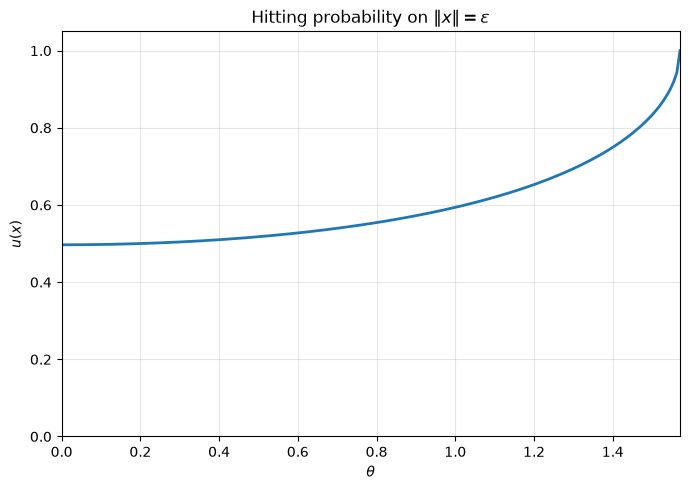

In [15]:
import matplotlib.pyplot as plt

# ============================================================
# Hitting probability on the hemisphere ||x|| = epsilon
# ============================================================

n_theta_plot = 200

theta = np.linspace(0.0, np.pi / 2.0, n_theta_plot)

u_epsilon = np.zeros_like(theta)

for i, th in enumerate(theta):

    # Hemisphere ||x|| = epsilon, x1 <= 0
    #
    # th = 0       -> (-epsilon, 0, 0)
    # th = pi / 2  -> (0, epsilon, 0)
    #
    x = np.array([
        -epsilon * np.cos(th),
        epsilon * np.sin(th),
        0.0
    ])

    u_epsilon[i] = solver.hitting_probability(x, sol)


# ------------------------------------------------------------
# Plot as a function of polar angle
# ------------------------------------------------------------

plt.figure(figsize=(7, 5))

plt.plot(
    theta,
    u_epsilon,
    linewidth=2
)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$u(x)$")

plt.title(
    r"Hitting probability on $\|x\|=\varepsilon$"
)

plt.xlim(0, np.pi / 2)
plt.ylim(0, 1.05)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

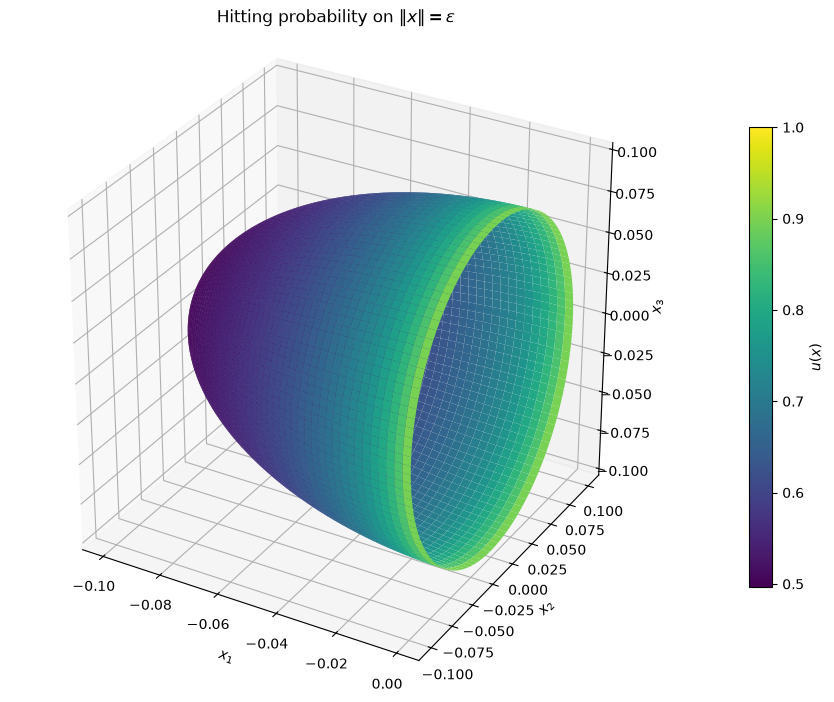

In [16]:
# ============================================================
# 3D visualization on the hemisphere ||x|| = epsilon
# ============================================================

n_theta = 60
n_phi = 120

theta_grid = np.linspace(0.0, np.pi / 2.0, n_theta)
phi_grid = np.linspace(0.0, 2.0 * np.pi, n_phi)

Theta, Phi = np.meshgrid(theta_grid, phi_grid)

X1 = -epsilon * np.cos(Theta)
X2 = epsilon * np.sin(Theta) * np.cos(Phi)
X3 = epsilon * np.sin(Theta) * np.sin(Phi)

# Because of axisymmetry, u depends only on theta.
u_theta = np.zeros(n_theta)

for j, th in enumerate(theta_grid):

    x = np.array([
        -epsilon * np.cos(th),
        epsilon * np.sin(th),
        0.0
    ])

    u_theta[j] = solver.hitting_probability(x, sol)


# Replicate around the symmetry axis
U = np.tile(u_theta, (n_phi, 1))


# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

fig = plt.figure(figsize=(9, 7))

ax = fig.add_subplot(
    111,
    projection="3d"
)

norm = plt.Normalize(
    vmin=np.min(U),
    vmax=np.max(U)
)

colors = plt.cm.viridis(norm(U))

surf = ax.plot_surface(
    X1,
    X2,
    X3,
    facecolors=colors,
    rstride=1,
    cstride=1,
    linewidth=0,
    antialiased=True,
    shade=False
)

mappable = plt.cm.ScalarMappable(
    cmap="viridis",
    norm=norm
)

mappable.set_array([])

fig.colorbar(
    mappable,
    ax=ax,
    shrink=0.7,
    pad=0.1,
    label=r"$u(x)$"
)

ax.set_xlabel(r"$x_1$")
ax.set_ylabel(r"$x_2$")
ax.set_zlabel(r"$x_3$")

ax.set_title(
    r"Hitting probability on $\|x\|=\varepsilon$"
)

ax.set_box_aspect([1, 1, 1])

plt.tight_layout()
plt.show()

In [17]:
class NarrowEscapeSolver4D(NarrowEscapeSolverD):
    """
    4D solver for a three-dimensional spherical absorbing window.

    Domain:
        Omega = {x1 <= 0, ||x|| < R} subset R^4

    Absorbing window:
        Gamma_a = {
            x1 = 0,
            x2^2 + x3^2 + x4^2 <= epsilon^2
        }

    By rotational symmetry in the transverse variables (x2,x3,x4),

        u = u(x1, r),

    with

        r = sqrt(x2^2 + x3^2 + x4^2).

    The flux on the absorbing 3-ball is written as

        q(rho) = phi(alpha) / (epsilon sin(alpha)),

        rho = epsilon cos(alpha),

        alpha in [0, pi/2].

    The angular integration over S^2 can be evaluated analytically.
    """

    def __init__(self, R, epsilon, N_alpha=20):
        super().__init__(
            d=4,
            R=R,
            epsilon=epsilon,
            N=N_alpha,
        )

        self.N_alpha = int(N_alpha)

    # ============================================================
    # Angular integration over S^2
    # ============================================================

    @staticmethod
    def _sphere2_kernel_integral(x1, r, s):
        r"""
        Computes

            J(x1,r,s)
              = integral_{S^2}
                  1 / |x-y|^2
                dOmega,

        where

            x = (x1, r, 0, 0)

        and y lies on a transverse sphere of radius s.

        Analytically,

            J =
            pi/(r*s)
            log(
                [x1^2 + (r+s)^2]
                /
                [x1^2 + (r-s)^2]
            ).

        Special cases r=0 and s=0 are treated separately.
        """

        a2 = x1 * x1

        # s = 0
        if s < 1e-14:
            denom = a2 + r * r

            if denom < 1e-28:
                return np.inf

            return 4.0 * np.pi / denom

        # r = 0
        if r < 1e-14:
            denom = a2 + s * s

            if denom < 1e-28:
                return np.inf

            return 4.0 * np.pi / denom

        numerator = a2 + (r + s) ** 2
        denominator = a2 + (r - s) ** 2

        if denominator <= 0.0:
            return np.inf

        return (
            np.pi
            / (r * s)
            * np.log(numerator / denominator)
        )

    # ============================================================
    # Angularly integrated half-ball Green function
    # ============================================================

    def _angular_kernel_interior(self, x1, r, s):
        r"""
        Computes

            Kbar(x1,r,s)
                = integral_{S^2}
                    G_half(x,y)
                  dOmega_y.

        In dimension 4,

            Phi_4(z) = 1/(4*pi^2 |z|^2).

        Reflection across x1=0 doubles the Green function for
        source points y on the flat boundary.
        """

        R = self.R

        # --------------------------------------------------------
        # Stable s -> 0 limit
        # --------------------------------------------------------

        if s < 1e-13:
            distance_sq = x1 * x1 + r * r

            if distance_sq < 1e-28:
                return np.inf

            # G_half at y = 0:
            #
            #   1/(2*pi^2) *
            #   (1/|x|^2 - 1/R^2)
            #
            # The angular integration over S^2 contributes 4*pi.
            return (
                2.0
                / np.pi
                * (
                    1.0 / distance_sq
                    - 1.0 / R**2
                )
            )

        # Direct contribution
        J1 = self._sphere2_kernel_integral(
            x1,
            r,
            s,
        )

        # Kelvin image
        s_star = R**2 / s

        J2 = self._sphere2_kernel_integral(
            x1,
            r,
            s_star,
        )

        return (
            J1
            - (R / s) ** 2 * J2
        ) / (2.0 * np.pi**2)

    def _angular_kernel_flat(self, r, s):
        """
        Same kernel when x1 = 0.
        """

        return self._angular_kernel_interior(
            0.0,
            r,
            s,
        )

    # ============================================================
    # Integral equation
    # ============================================================

    def assemble_system(self):
        r"""
        Solve the axisymmetric boundary integral equation.

        The absorbing window is now a 3-dimensional ball.

        Its surface measure is

            dS = rho^2 d(rho) dOmega_2.

        Using

            rho = epsilon cos(beta),

        and

            q(rho)
              = phi(beta)/(epsilon sin(beta)),

        gives the cancellation

            q dS
              =
              phi(beta)
              epsilon^2 cos^2(beta)
              d(beta) dOmega_2.

        Therefore

            A_ij =
                integral_cell_j
                    epsilon^2 cos^2(beta)
                    Kbar(r_i, epsilon cos(beta))
                d beta.
        """

        edges = np.linspace(
            0.0,
            np.pi / 2.0,
            self.N_alpha + 1,
        )

        alpha_nodes = 0.5 * (
            edges[:-1] + edges[1:]
        )

        rho_nodes = (
            self.epsilon
            * np.cos(alpha_nodes)
        )

        A = np.zeros(
            (self.N_alpha, self.N_alpha)
        )

        rhs = np.ones(self.N_alpha)

        for i, r_i in enumerate(rho_nodes):

            alpha_i = alpha_nodes[i]

            for j in range(self.N_alpha):

                left = edges[j]
                right = edges[j + 1]

                def integrand(beta):

                    # Integrable logarithmic singularity.
                    if abs(beta - alpha_i) < 1e-14:
                        return 0.0

                    s = (
                        self.epsilon
                        * np.cos(beta)
                    )

                    return (
                        self.epsilon**2
                        * np.cos(beta)**2
                        * self._angular_kernel_flat(
                            r_i,
                            s,
                        )
                    )

                quad_kwargs = dict(
                    epsabs=1e-10,
                    epsrel=1e-10,
                    limit=200,
                )

                if left < alpha_i < right:

                    value, _ = quad(
                        integrand,
                        left,
                        right,
                        points=[alpha_i],
                        **quad_kwargs,
                    )

                else:

                    value, _ = quad(
                        integrand,
                        left,
                        right,
                        **quad_kwargs,
                    )

                A[i, j] = value

        phi = solve(A, rhs)

        q_nodes = phi / (
            self.epsilon
            * np.sin(alpha_nodes)
        )

        return {
            "phi": phi,
            "q": q_nodes,
            "A": A,
            "rhs": rhs,
            "alpha_edges": edges,
            "alpha_nodes": alpha_nodes,
            "rho_nodes": rho_nodes,
            "residual": np.linalg.norm(
                A @ phi - rhs,
                ord=np.inf,
            ),
            "cond": np.linalg.cond(A),
        }

    # ============================================================
    # Evaluate u(x)
    # ============================================================

    def hitting_probability(self, x, solution):
        """
        Evaluate u(x) for x in R^4.
        """

        x = np.asarray(x, dtype=float)

        if x.shape != (4,):
            raise ValueError(
                "x must be a four-dimensional vector."
            )

        norm_x = np.linalg.norm(x)

        transverse_r = np.linalg.norm(
            x[1:]
        )

        tol = 1e-11 * max(
            1.0,
            self.R,
        )

        if norm_x > self.R + tol:
            raise ValueError(
                "x lies outside the half-ball."
            )

        if x[0] > tol:
            raise ValueError(
                "x must satisfy x1 <= 0."
            )

        # Outer absorbing boundary
        if abs(norm_x - self.R) <= tol:
            return 0.0

        # Small absorbing 3-ball
        if (
            abs(x[0]) <= tol
            and transverse_r <= self.epsilon + tol
        ):
            return 1.0

        phi = solution["phi"]
        edges = solution["alpha_edges"]

        u = 0.0

        for j in range(self.N_alpha):

            left = edges[j]
            right = edges[j + 1]

            def integrand(beta):

                s = (
                    self.epsilon
                    * np.cos(beta)
                )

                return (
                    self.epsilon**2
                    * np.cos(beta)**2
                    * self._angular_kernel_interior(
                        x[0],
                        transverse_r,
                        s,
                    )
                )

            value, _ = quad(
                integrand,
                left,
                right,
                epsabs=1e-10,
                epsrel=1e-10,
                limit=200,
            )

            u += phi[j] * value

        return float(u)

In [22]:
if __name__ == "__main__":

    R = 10.0
    epsilon = 0.01
    N_alpha = 20

    solver4 = NarrowEscapeSolver4D(
        R=R,
        epsilon=epsilon,
        N_alpha=N_alpha,
    )

    print(
        "Assembling the 4D axisymmetric integral equation..."
    )

    sol4 = solver4.assemble_system()

    print(
        f"Residual:         "
        f"{sol4['residual']:.3e}"
    )

    print(
        f"Condition number: "
        f"{sol4['cond']:.3e}"
    )

    print(
        "phi range:        "
        f"[{sol4['phi'].min():.6e}, "
        f"{sol4['phi'].max():.6e}]"
    )

    # Interior point in R^4
    x_test = np.array([
        -2.0,
        0.0,
        0.5,
        0.2,
    ])

    prob = solver4.hitting_probability(
        x_test,
        sol4,
    )

    print(
        f"u({x_test}) = {prob:.6f}"
    )

    # Center of absorbing window
    x_window = np.array([
        0.0,
        0.0,
        0.0,
        0.0,
    ])

    print(
        "u on window       = "
        f"{solver4.hitting_probability(x_window, sol4):.6f}"
    )

    # Outer hypersphere
    x_outer = np.array([
        -R,
        0.0,
        0.0,
        0.0,
    ])

    print(
        "u on outer sphere = "
        f"{solver4.hitting_probability(x_outer, sol4):.6f}"
    )

Assembling the 4D axisymmetric integral equation...
Residual:         2.220e-16
Condition number: 4.081e+01
phi range:        [1.000000e+00, 1.000001e+00]
u([-2.   0.   0.5  0.2]) = 0.000011
u on window       = 1.000000
u on outer sphere = 0.000000


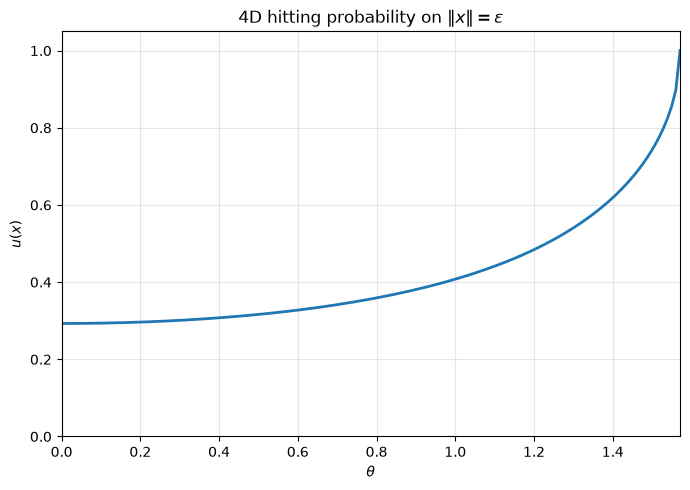

In [23]:
import matplotlib.pyplot as plt

theta = np.linspace(
    0.0,
    np.pi / 2.0,
    150,
)

u_eps_4d = np.zeros_like(theta)

for i, th in enumerate(theta):

    x = np.array([
        -epsilon * np.cos(th),
        epsilon * np.sin(th),
        0.0,
        0.0,
    ])

    u_eps_4d[i] = solver4.hitting_probability(
        x,
        sol4,
    )

plt.figure(figsize=(7, 5))

plt.plot(
    theta,
    u_eps_4d,
    linewidth=2,
)

plt.xlabel(r"$\theta$")
plt.ylabel(r"$u(x)$")

plt.title(
    r"4D hitting probability on "
    r"$\|x\|=\varepsilon$"
)

plt.xlim(
    0,
    np.pi / 2,
)

plt.ylim(
    0,
    1.05,
)

plt.grid(
    True,
    alpha=0.3,
)

plt.tight_layout()
plt.show()